In [ ]:
!uv pip install -q torchaudio
!uv pip install -q torchcodec
!uv pip install -q torch
!uv pip install -q tensorflow tensorflow-io
!uv pip install -q tensorflow_hub
!uv pip install -q datasets[audio]
!uv pip install -q protobuf

In [ ]:
import os

from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_io as tfio


/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl5mutex6unlockEv']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZNK10tensorflow4data11DatasetBase8FinalizeEPNS_15OpKernelContextESt8functionIFN4absl12lts_202

In [ ]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("BigTrev89/humbugdb-audio")

README.md:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

data/train-00000-of-00009.parquet: reconstructing file:   0%|          |  0.00B /  380MB            

data/train-00000-of-00009.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00009.parquet: reconstructing file:   0%|          |  0.00B /  724MB            

data/train-00001-of-00009.parquet: downloading bytes:           |  0.00B            

...

data/train-00007-of-00009.parquet: downloading bytes:           |  0.00B            

data/train-00008-of-00009.parquet: reconstructing file:   0%|          |  0.00B /  819MB            

data/train-00008-of-00009.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/9295 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['id', 'length', 'name', 'sample_rate', 'record_datetime', 'sound_type', 'species', 'gender', 'fed', 'plurality', 'age', 'method', 'mic_type', 'device_type', 'country', 'district', 'province', 'place', 'location_type', 'audio'],
        num_rows: 9295
    })
})

In [ ]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt


species_counts = Counter(ds['train']['species'])

# Sort the data for the plot
sorted_counts = dict(sorted(species_counts.items(), key=lambda item: item[1], reverse=True))
species_labels = list(sorted_counts.keys())
counts = list(sorted_counts.values())

print(f"Total unique species: {len(species_labels)}")

Total unique species: 39


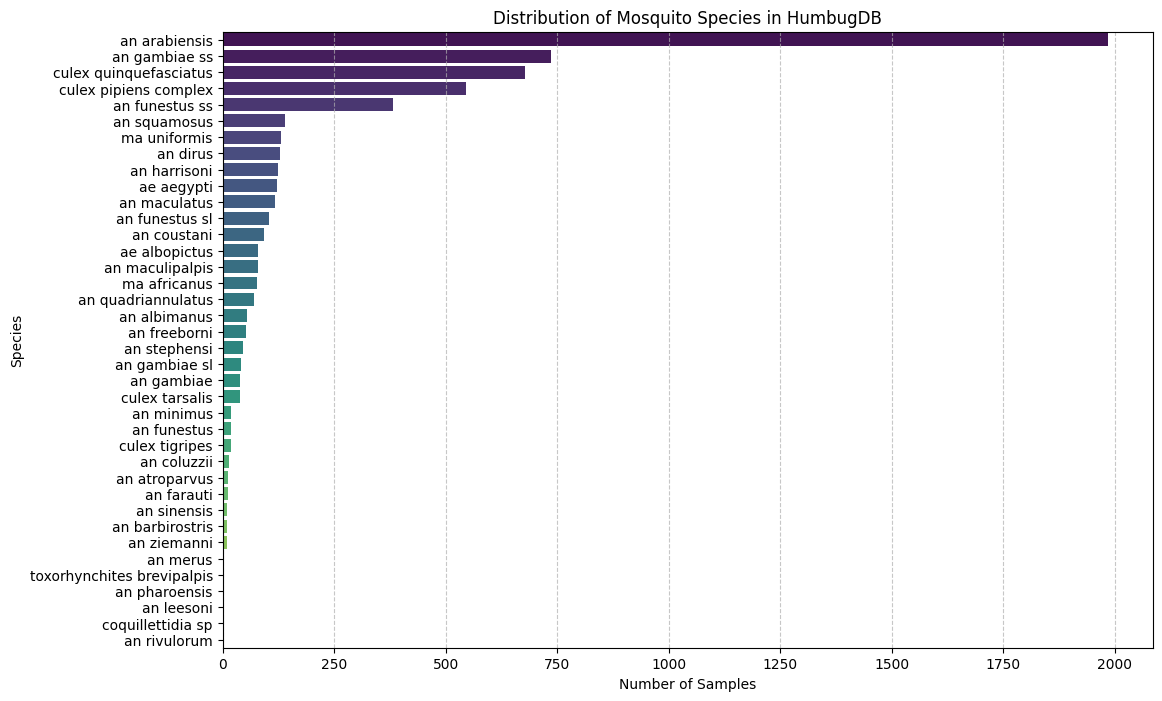

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(y=species_labels, x=counts, hue=species_labels, palette='viridis', legend=False)
plt.title('Distribution of Mosquito Species in HumbugDB')
plt.xlabel('Number of Samples')
plt.ylabel('Species')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Access the count for 'None' which represents unknown species
unknown_count = species_counts.get(None, 0)
print(f"Number of samples with unknown species (None): {unknown_count}")

# Calculate percentage
total_samples = sum(species_counts.values())
percentage = (unknown_count / total_samples) * 100
print(f"Percentage of unknown species: {percentage:.2f}%")

Number of samples with unknown species (None): 3287
Percentage of unknown species: 35.36%


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# 1. Identify indices where species is NOT None
# We iterate through the 'species' column to find indices
valid_indices = [i for i, species in enumerate(ds['train']['species']) if species is not None]

# 2. Extract country for those specific indices
# Using select() is efficient for sub-sampling without loading all audio
countries_filtered = ds['train'].select(valid_indices)['country']

# 3. Count occurrences
country_counts = Counter(countries_filtered)

# Prepare data for pie chart
labels = list(country_counts.keys())
sizes = list(country_counts.values())

print(f"Samples with known species: {len(valid_indices)}")
print(f"Country breakdown: {dict(country_counts)}")

Samples with known species: 6008
Country breakdown: {'USA': 513, 'UK': 687, 'Tanzania': 3702, 'Kenya': 737, 'Thailand': 369}


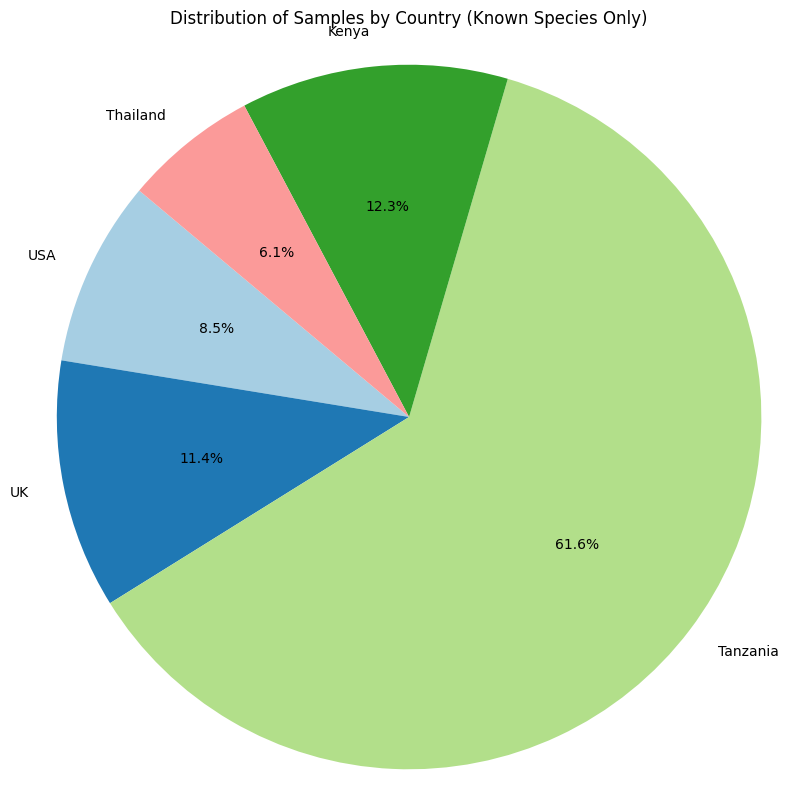

In [ ]:
plt.figure(figsize=(10, 10))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of Samples by Country (Known Species Only)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# 1. Filter for Tanzania and valid species
tz_indices = [i for i, (country, species) in enumerate(zip(ds['train']['country'], ds['train']['species']))
              if country == 'Tanzania' and species is not None]

# 2. Extract species for these indices
tz_species = ds['train'].select(tz_indices)['species']
tz_species_counts = Counter(tz_species)

# 3. Prepare data for plotting
tz_labels = list(tz_species_counts.keys())
tz_sizes = list(tz_species_counts.values())

print(f"Total samples from Tanzania with known species: {len(tz_indices)}")
print(f"Species breakdown in Tanzania: {dict(tz_species_counts)}")
print(f"Total unique species in Tanzania: {len(tz_labels)}")

Total samples from Tanzania with known species: 3702
Species breakdown in Tanzania: {'ma africanus': 78, 'an arabiensis': 1984, 'ma uniformis': 131, 'culex pipiens complex': 545, 'an funestus ss': 381, 'an funestus sl': 104, 'an ziemanni': 9, 'an pharoensis': 3, 'an gambiae sl': 42, 'culex tigripes': 18, 'an leesoni': 3, 'ae aegypti': 89, 'an squamosus': 141, 'an coustani': 92, 'an rivulorum': 1, 'coquillettidia sp': 2, 'an maculipalpis': 79}
Total unique species in Tanzania: 17


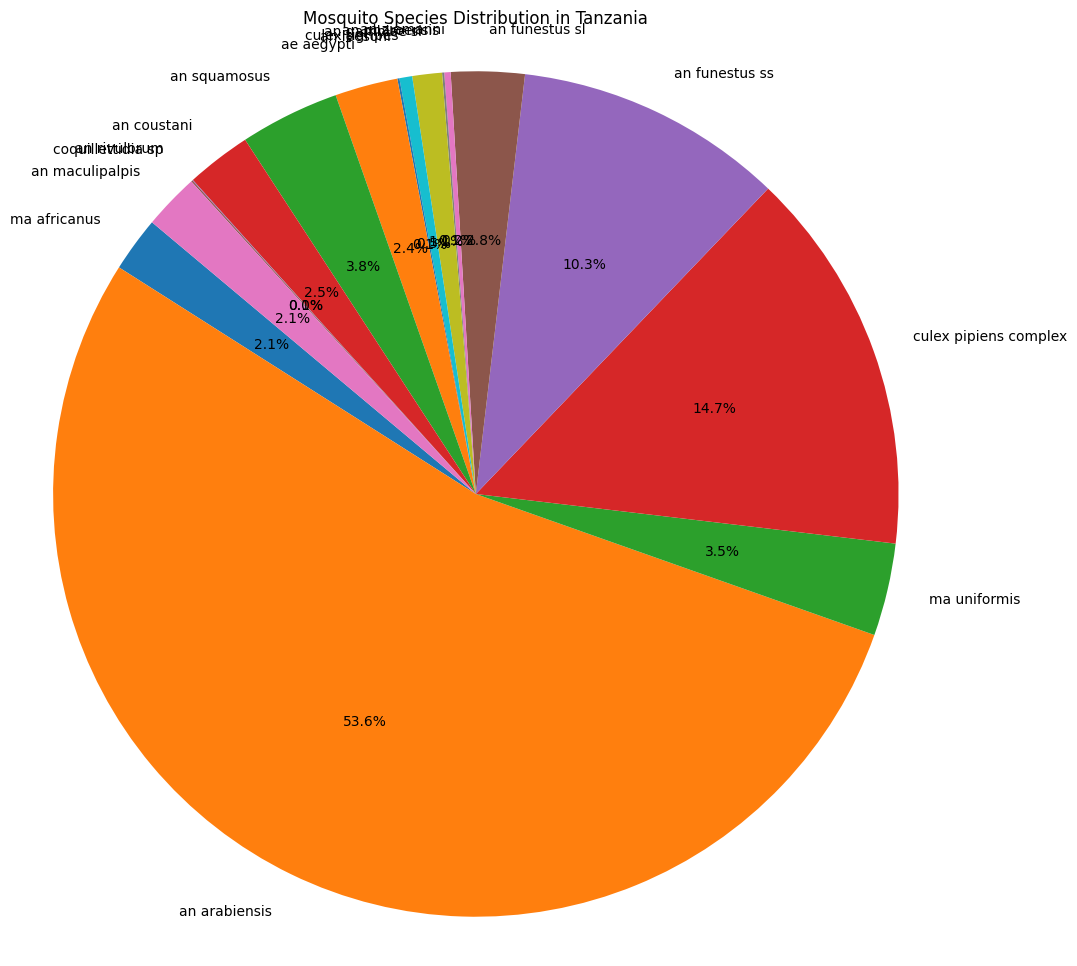

In [ ]:
plt.figure(figsize=(12, 12))
plt.pie(tz_sizes, labels=tz_labels, autopct='%1.1f%%', startangle=140)
plt.title('Mosquito Species Distribution in Tanzania')
plt.axis('equal')
plt.show()

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# 1. Filter for Kenya and valid species
kenya_indices = [i for i, (country, species) in enumerate(zip(ds['train']['country'], ds['train']['species']))
                 if country == 'Kenya' and species is not None]

# 2. Extract species for these indices and count
kenya_species = ds['train'].select(kenya_indices)['species']
kenya_species_counts = Counter(kenya_species)

# 3. Prepare data for plotting
kenya_labels = list(kenya_species_counts.keys())
kenya_sizes = list(kenya_species_counts.values())

print(f"Total samples from Kenya with known species: {len(kenya_indices)}")
print(f"Species breakdown in Kenya: {dict(kenya_species_counts)}")

Total samples from Kenya with known species: 737
Species breakdown in Kenya: {'an gambiae ss': 737}


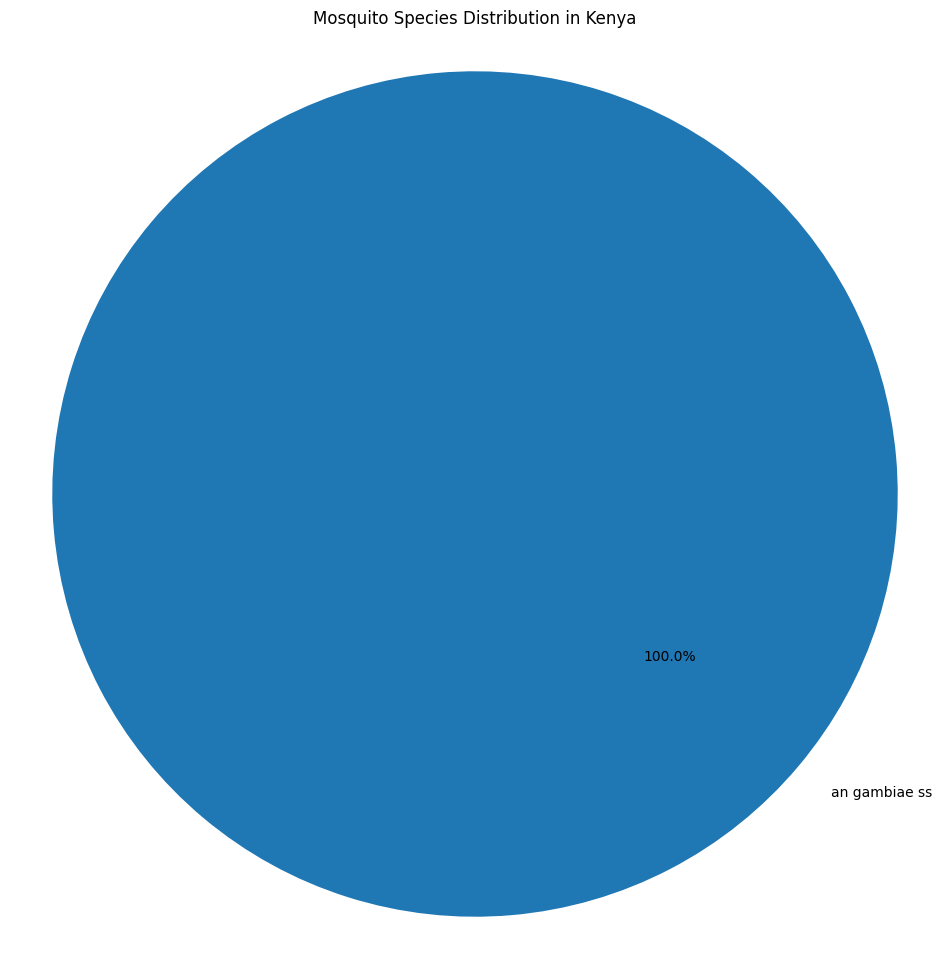

In [ ]:
plt.figure(figsize=(12, 12))
plt.pie(kenya_sizes, labels=kenya_labels, autopct='%1.1f%%', startangle=140)
plt.title('Mosquito Species Distribution in Kenya')
plt.axis('equal')
plt.show()